In [22]:
# 데이터 생성(문제와 정답)

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

dataset = pd.read_csv('다항회귀_성적.csv')

In [23]:
# 독립 변수, 종속 변수 분리(문제와 정답을 분리)

X = dataset.iloc[:, :-1] # 독립 변수(학습시간)
y = dataset.iloc[:, -1] # 종속 변수(성적)

In [24]:
# 훈련 데이터, 테스트 데이터 분리(기출문제, 모의고사를 분리)
# test_size=0.2는 전체의 20%를 테스트용으로 쓰겠다는 의미
# random_state는 실행할 때마다 결과가 달라지지 않도록 고정하는 값

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# 다항식 변환 : 다항식을 표현하기 위해 직선을 이용 => 차수에 맞게 데이터를 늘림

# 다항 차수 설정(2차항까지). b는 포함 안함
poly = PolynomialFeatures(degree=2, include_bias=False)

# 변환 실행
X_train_poly = poly.fit_transform(X_train)


In [26]:
# 학습
reg = LinearRegression()
reg.fit(X_train_poly, y_train)
# 테스트 데이터도 똑같은 차수로 변환
X_test_poly = poly.transform(X_test)

In [27]:
# 성능 확인(테스트 데이터를 이용)
train_score = reg.score(X_train_poly, y_train)
test_score = reg.score(X_test_poly, y_test)

print(f"훈련 세트 점수: {train_score:.2f}")
print(f"테스트 세트 점수: {test_score:.2f}")

훈련 세트 점수: 0.98
테스트 세트 점수: 0.95


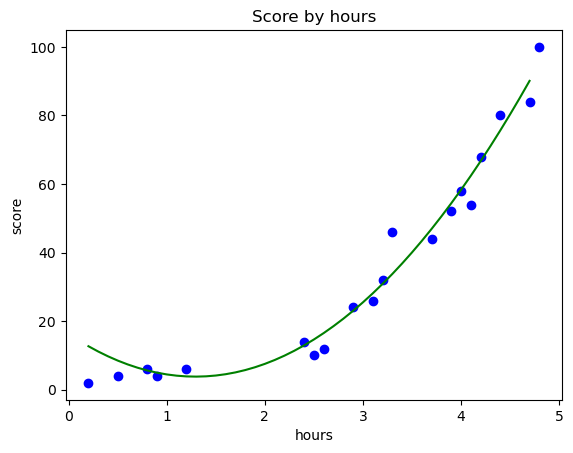

In [28]:
# 데이터 시각화
x_range = np.arange(X.min().item(), X.max().item(), 0.1) # x의 최소값에서 최대값까지의 범위를 0.1 단위로 잘라서 데이터를 생성
x_range = x_range.reshape(-1, 1) # row 개수는 자동으로 계산, column 개수는 1개

plt.scatter(X, y, color='blue')
plt.plot(x_range, reg.predict(poly.fit_transform(x_range)), color='green')
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()